In [7]:
!uv pip install pandas biopandas biotite hydride

Checked 4 packages in 22ms


In [8]:
!uv pip install propka

Checked 1 package in 3ms


In [12]:
import os
import tempfile
import warnings
import numpy as np

import biotite.structure as struc
import biotite.structure.io.pdb as pdb
import hydride
from propka.run import single as run_propka

warnings.filterwarnings("ignore")

def run_hypothesis_benchmark(pdb_path: str, scale_factor: float = 1.01, ph: float = 7.0):
    if not os.path.exists(pdb_path):
        print(f" Error: File '{pdb_path}' not found in current directory ({os.getcwd()}).")
        return

    print(f" Loading starting structure from '{pdb_path}'...")
    pdb_file = pdb.PDBFile.read(pdb_path)
    array = pdb.get_structure(pdb_file, model=1)

    # Strip existing Hydrogens and non-amino acid heteroatoms (metals, water)
    protein_mask = struc.filter_amino_acids(array) & (array.element != "H") & (array.element != "D")
    heavy_array = array[protein_mask]

    # Estimate formal charges at target pH using native geometry
    heavy_array.charge = hydride.estimate_amino_acid_charges(heavy_array, ph=ph)

    # Connect topology/bonds on heavy atoms (native geometry)
    heavy_array.bonds = struc.connect_via_residue_names(heavy_array)

    # Add Hydrogens using Hydride on unscaled structure
    print("Running Hydride to place protons...")
    protein_array, _ = hydride.add_hydrogen(heavy_array)
    h_count = np.sum(protein_array.element == "H")
    print(f"   SUCCESS: Hydride placed {h_count} protons.")

    # Execute PROPKA on the unscaled, hydrated structure
    print("Running PROPKA on unscaled structure...")
    pkas = {}
    try:
        with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+", delete=False) as tmp:
            tmp_path = tmp.name
            out_file = pdb.PDBFile()
            out_file.set_structure(protein_array)
            out_file.write(tmp_path)

        pk_molecule = run_propka(tmp_path, write_pka=False, optargs=["--quiet"])
        
        # Cleanup temp file
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

        # Parse calculated pKas
        for group in pk_molecule.conformations['conformation container'].groups:
            res_key = f"{group.atom.res_name}{group.atom.res_num}"
            pkas[res_key] = group.pka_value

        print(f"   SUCCESS: PROPKA computed pKa values for {len(pkas)} residues.")
        print("\n--- Sample Calculated pKa Values ---")
        for res, pka_val in list(pkas.items())[:10]:
            print(f"   {res:<8} : {pka_val:.2f}")
        print("   ...")

    except Exception as e:
        print(f"   FAILED: {e}")

    # Apply spatial scaling matrix AFTER PROPKA calculations
    print(f"\n Scaling final hydrated structure outward by {((scale_factor - 1) * 100):.1f}% (Scale Factor = {scale_factor})...")
    centroid = struc.centroid(protein_array)
    protein_array.coord = (protein_array.coord - centroid) * scale_factor + centroid

    print("Pipeline completed successfully.")
    return protein_array, pkas

# Run pipeline
scaled_structure, pka_dict = run_hypothesis_benchmark("1c57.pdb", scale_factor=1.01, ph=7.0)

 Loading starting structure from '1c57.pdb'...
Running Hydride to place protons...
   SUCCESS: Hydride placed 1755 protons.
Running PROPKA on unscaled structure...
   FAILED: 'conformation container'

 Scaling final hydrated structure outward by 1.0% (Scale Factor = 1.01)...
Pipeline completed successfully.


In [13]:
import os
import tempfile
import warnings
import numpy as np
import pandas as pd  

import biotite.structure as struc
import biotite.structure.io.pdb as pdb
import hydride
from propka.run import single as run_propka

warnings.filterwarnings("ignore")

def run_hypothesis_benchmark(pdb_path: str, scale_factor: float = 1.01, ph: float = 7.0):
    if not os.path.exists(pdb_path):
        print(f"Error: File '{pdb_path}' not found in current directory ({os.getcwd()}).")
        return None, {}

    print(f" Loading starting structure from '{pdb_path}'...")
    pdb_file = pdb.PDBFile.read(pdb_path)
    array = pdb.get_structure(pdb_file, model=1)

    #  Isolate heavy protein atoms (strip H, water, heteroatoms)
    protein_mask = struc.filter_amino_acids(array) & (array.element != "H") & (array.element != "D")
    heavy_array = array[protein_mask]

    # run propka first on clean heavy-atom geometry
    print("🧬 Running PROPKA on native heavy-atom structure...")
    pkas = {}
    try:
        with tempfile.NamedTemporaryFile(suffix=".pdb", mode="w+", delete=False) as tmp:
            tmp_path = tmp.name
            out_file = pdb.PDBFile()
            out_file.set_structure(heavy_array)
            out_file.write(tmp_path)

        pk_molecule = run_propka(tmp_path, write_pka=False, optargs=["--quiet"])
        
        if os.path.exists(tmp_path):
            os.remove(tmp_path)

        # Access conformation container 
        conf = pk_molecule.conformations['1A']
        for group in conf.groups:
            res_key = f"{group.atom.res_name}{group.atom.res_num}"
            pkas[res_key] = group.pka_value

        print(f"   SUCCESS: PROPKA computed pKa values for {len(pkas)} residues.")
        print("\n- Sample Calculated pKa Values -")
        for res, pka_val in list(pkas.items())[:10]:
            print(f"   {res:<8} : {pka_val:.2f}")
        print("   ...")

    except Exception as e:
        print(f"   FAILED PROPKA: {e}")

    # Assign formal charges & topology for Hydride
    heavy_array.charge = hydride.estimate_amino_acid_charges(heavy_array, ph=ph)
    heavy_array.bonds = struc.connect_via_residue_names(heavy_array)

    # Add Hydrogens with Hydride
    print("\n Running Hydride to place protons...")
    protein_array, _ = hydride.add_hydrogen(heavy_array)
    h_count = np.sum(protein_array.element == "H")
    print(f"   SUCCESS: Hydride placed {h_count} protons.")

    # Apply spatial scaling matrix (Scale outward relative to centroid)
    print(f"\n Scaling final structure outward by {((scale_factor - 1) * 100):.1f}% (Scale Factor = {scale_factor})...")
    centroid = struc.centroid(protein_array)
    protein_array.coord = (protein_array.coord - centroid) * scale_factor + centroid

    print("\n Pipeline completed successfully.")
    return protein_array, pkas



# Run benchmark
scaled_structure, pka_dict = run_hypothesis_benchmark("1c57.pdb", scale_factor=1.01, ph=7.0)

# Convert pKa dictionary to a structured pandas DataFrame
data = []
for res_key, pka_val in pka_dict.items():
    res_name = res_key[:3]          
    res_num = int(res_key[3:])       
    data.append({
        "residue_key": res_key,
        "residue_name": res_name,
        "residue_number": res_num,
        "pka_calculated": round(pka_val, 2)
    })

df_pka_aniso = pd.DataFrame(data)

# write CSV
output_dir = "data/outputs"
os.makedirs(output_dir, exist_ok=True)

csv_path = os.path.join(output_dir, "Uniform-Scale.csv")
df_pka_aniso.to_csv(csv_path, index=False)

print("\n Dataset compiled successfully!")
print(f" Saved results to: {csv_path}\n")
print(df_pka_aniso.head(10))

 Loading starting structure from '1c57.pdb'...
🧬 Running PROPKA on native heavy-atom structure...
   SUCCESS: PROPKA computed pKa values for 237 residues.

- Sample Calculated pKa Values -
   ALA1     : 0.00
   ASP2     : 2.62
   THR3     : 0.00
   ILE4     : 0.00
   VAL5     : 0.00
   ALA6     : 0.00
   VAL7     : 0.00
   GLU8     : 4.08
   LEU9     : 0.00
   ASP10    : 9.66
   ...

 Running Hydride to place protons...
   SUCCESS: Hydride placed 1755 protons.

 Scaling final structure outward by 1.0% (Scale Factor = 1.01)...

 Pipeline completed successfully.

 Dataset compiled successfully!
 Saved results to: data/outputs/Uniform-Scale.csv

  residue_key residue_name  residue_number  pka_calculated
0        ALA1          ALA               1            0.00
1        ASP2          ASP               2            2.62
2        THR3          THR               3            0.00
3        ILE4          ILE               4            0.00
4        VAL5          VAL               5            

In [16]:
!uv pip install adjustText seaborn

Resolved 15 packages in 243ms                                        
Installed 1 package in 170ms                                
 + seaborn==0.13.2


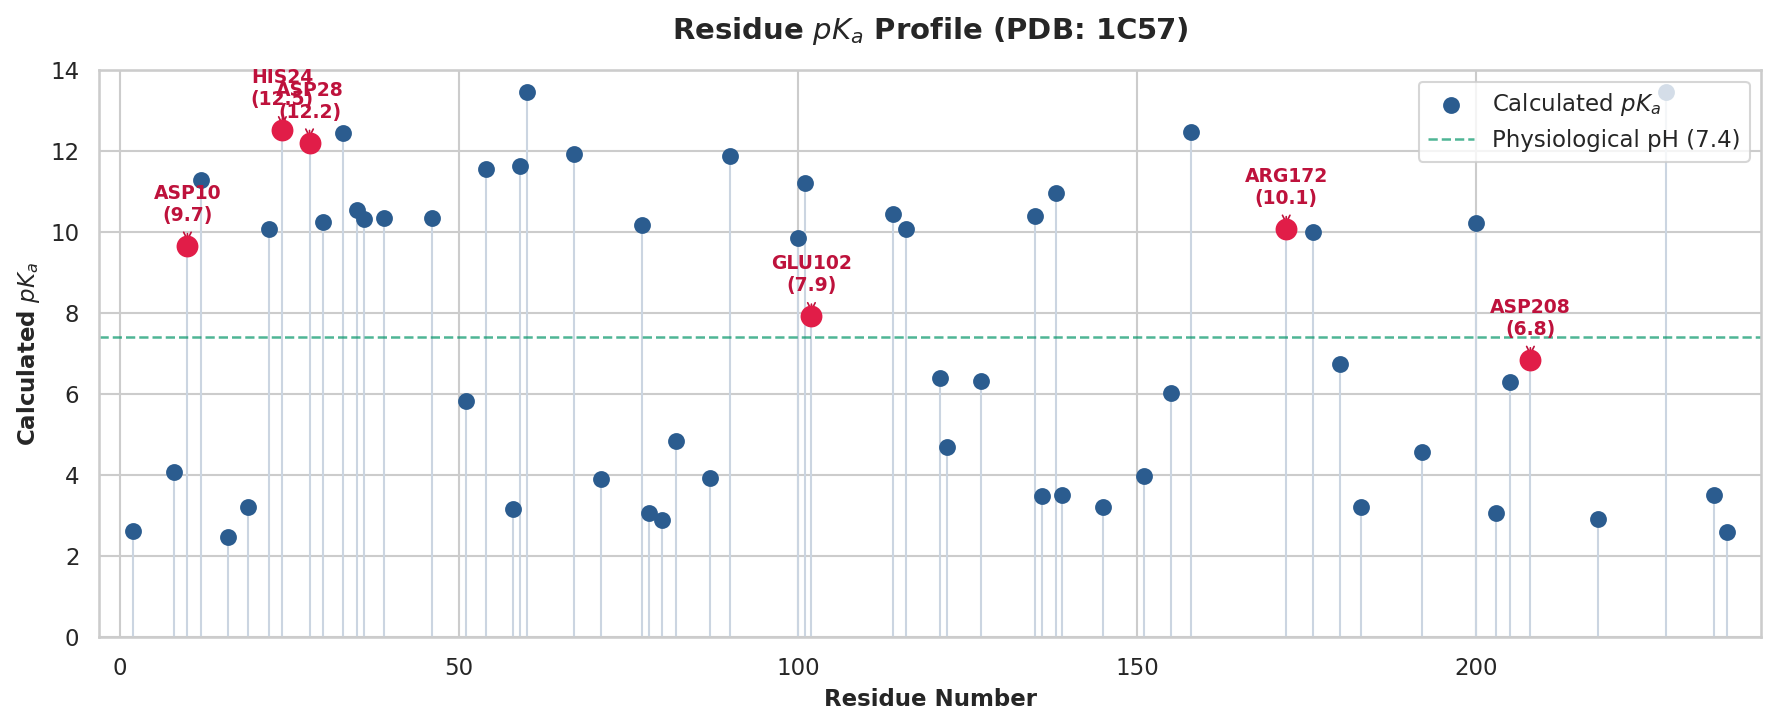

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.clf()
plt.close('all')


titratable_pka = {res: val for res, val in pka_dict.items() if val > 0.0}

res_labels = list(titratable_pka.keys())
res_numbers = [int(''.join(filter(str.isdigit, res))) for res in res_labels]
res_names = [''.join(filter(str.isalpha, res)) for res in res_labels]
pka_values = list(titratable_pka.values())

pka_baselines = {
    'ASP': 3.9, 'GLU': 4.3, 'HIS': 6.0, 
    'CYS': 8.3, 'TYR': 10.1, 'LYS': 10.5, 'ARG': 12.5
}

# Plot
plt.figure(figsize=(12, 5), dpi=150)
sns.set_theme(style="whitegrid")

plt.scatter(res_numbers, pka_values, color="#2b5c8f", s=50, zorder=3, label="Calculated $p K_a$")
plt.vlines(res_numbers, ymin=0, ymax=pka_values, colors="#cbd5e1", linewidth=1, zorder=2)

# Keep track of annotated residues to prevent any possibility of duplicate text
annotated_residues = set()

for num, name, val in zip(res_numbers, res_names, pka_values):
    res_id = f"{name}{num}"
    baseline = pka_baselines.get(name, None)
    
    if baseline and abs(val - baseline) > 2.0 and res_id not in annotated_residues:
        annotated_residues.add(res_id)
        
        plt.scatter(num, val, color="#e11d48", s=90, zorder=4)
        plt.annotate(
            f"{res_id}\n({val:.1f})",
            (num, val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9,
            fontweight='bold',
            color="#be123c",
            arrowprops=dict(arrowstyle="->", color="#be123c", lw=0.8)
        )

plt.title("Residue $p K_a$ Profile (PDB: 1C57)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Residue Number", fontsize=11, fontweight="bold")
plt.ylabel("Calculated $p K_a$", fontsize=11, fontweight="bold")
plt.ylim(0, 14)
plt.xlim(min(res_numbers) - 5, max(res_numbers) + 5)
plt.axhline(7.4, color="#059669", linestyle="--", linewidth=1.2, alpha=0.7, label="Physiological pH (7.4)")

plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()